In [147]:
import pandas as pd
import numpy as np

In [148]:
df = pd.read_csv('features.csv')

# Filter where the first column equals "Linear"
linear = df[df.iloc[:, 0] == "Linear"].copy()


In [149]:
# Select input features (X) and output conditions (y)
X = linear.iloc[:, 3:linear.shape[1]]
y = linear.iloc[:, 1]

X.head(5)

,PlateHFAccZ_mean,PlateHFAccZ_rms,PlateHFAccZ_std,PlateHFAccZ_kurtosis,PlateHFAccZ_skewness,PlateHFAccZ_peak_to_peak,PlateHFAccZ_energy,PlateHFAccZ_crest_factor,PlateHFAccZ_shape_factor,PlateHFAccZ_impulse_factor,...,SpindleAccZ_rms,SpindleAccZ_std,SpindleAccZ_kurtosis,SpindleAccZ_skewness,SpindleAccZ_peak_to_peak,SpindleAccZ_energy,SpindleAccZ_crest_factor,SpindleAccZ_shape_factor,SpindleAccZ_impulse_factor,SpindleAccZ_margin_factor
0,-0.144735,0.145728,0.016981,-0.007792,-0.007584,0.147292,0.021237,1.467813,1.006859,1.477880,...,0.069887,0.059787,-0.080899,0.184036,0.486578,0.004884,3.787448,1.269562,4.808402,5.728563
1,-0.144676,0.145680,0.017069,0.008340,0.010004,0.143927,0.021223,1.519616,1.006936,1.530156,...,0.069057,0.059353,-0.104696,0.187289,0.444495,0.004769,3.616597,1.271620,4.598936,5.490007
2,-0.144918,0.145916,0.017040,-0.015232,0.003715,0.148787,0.021292,1.494098,1.006890,1.504391,...,0.068992,0.059596,-0.109096,0.184334,0.482797,0.004760,3.714598,1.270997,4.721243,5.630458
3,-0.144847,0.145838,0.016966,0.000061,-0.005515,0.147666,0.021269,1.512845,1.006836,1.523187,...,0.069030,0.059654,-0.133125,0.179394,0.458462,0.004765,3.997931,1.270782,5.080499,6.063244
4,-0.145517,0.146515,0.017077,0.004872,0.003330,0.149909,0.021467,1.516055,1.006863,1.526459,...,0.069064,0.059565,-0.088008,0.194710,0.453705,0.004770,3.841403,1.273509,4.892060,5.845710


In [150]:
from sklearn.model_selection import train_test_split

# Apply random 65:35 (training:test) split to the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=21)

In [151]:
# Normalise all variables
from sklearn.preprocessing import StandardScaler

scale_standard = StandardScaler()

X_train = scale_standard.fit_transform(X_train)


# Revert back to pandas data frame
X_train = pd.DataFrame(X_train, columns=[X.columns.values.tolist()])


In [152]:
from sklearn.decomposition import PCA

# Compute a 3 component PCA
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_train)

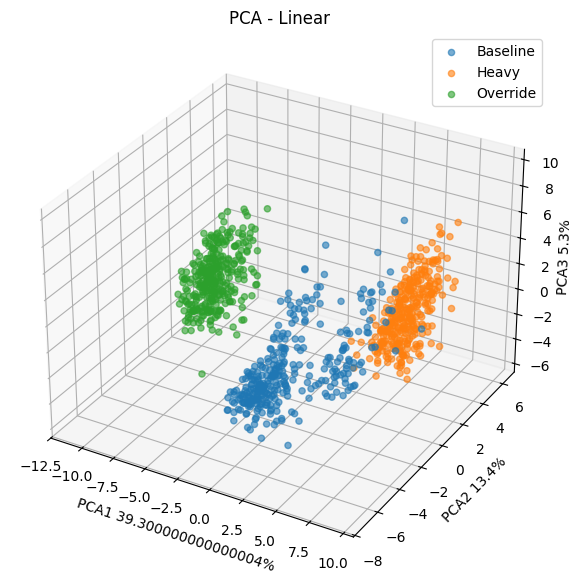

In [153]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')

# Loop through each unique category and plot them separately
for condition in np.unique(y_train):
    # Create a mask to isolate only the current condition's rows
    mask = (y_train == condition)
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        X_pca[mask, 2],      
        label=condition, 
        alpha=0.6
    )

# Label all axes with percentage of explained variance
ax.set_xlabel(f'PCA1 {pca.explained_variance_ratio_[0].round(3)*100}%')
ax.set_ylabel(f'PCA2 {pca.explained_variance_ratio_[1].round(3)*100}%')
ax.set_zlabel(f'PCA3 {pca.explained_variance_ratio_[2].round(3)*100}%', labelpad=-1)
# Graph title
ax.set_title("PCA - Linear")

# Add a legend
ax.legend(loc='upper right')
plt.show()

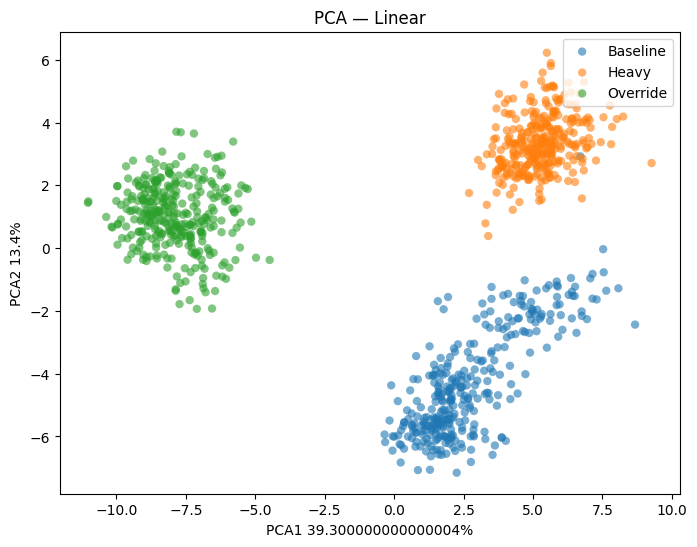

In [154]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(8, 6))

# Loop through each unique category and plot them separately
for condition in np.unique(y_train):
    # Create a mask to isolate only the current condition's rows
    mask = (y_train == condition)
    
    # Plot just this group
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        label=condition,      
        alpha=0.6,           
        edgecolors='none'     
    )

# Standard axis labeling
ax.set_xlabel(f'PCA1 {pca.explained_variance_ratio_[0].round(3)*100}%')
ax.set_ylabel(f'PCA2 {pca.explained_variance_ratio_[1].round(3)*100}%')
ax.set_title('PCA — Linear')

# Add a legend
ax.legend(loc='upper right', scatterpoints=1, frameon=True)

plt.show()